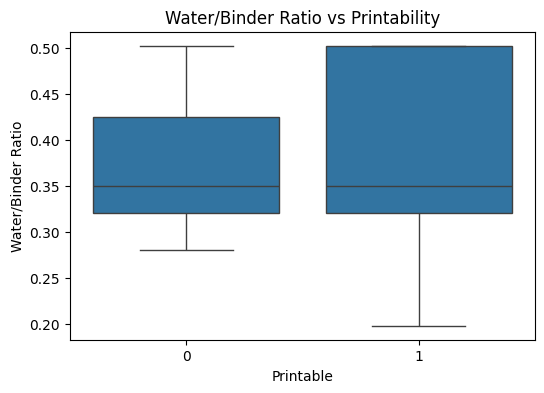

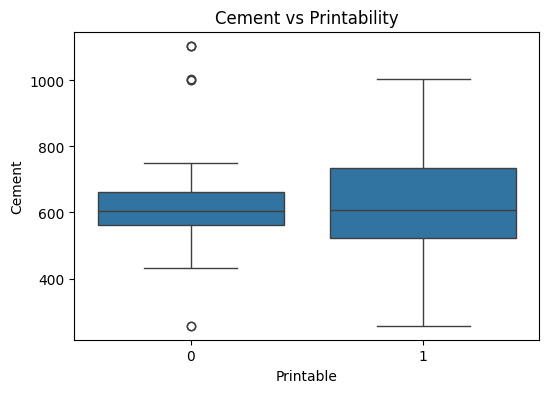

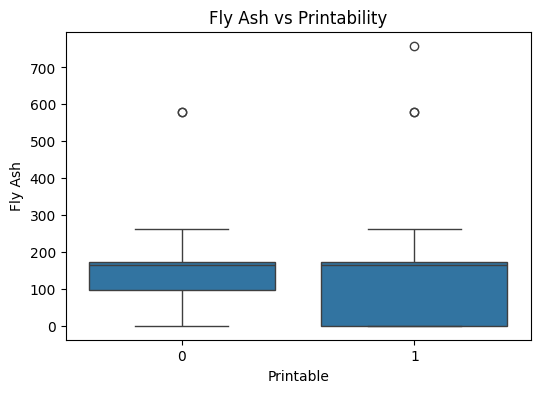

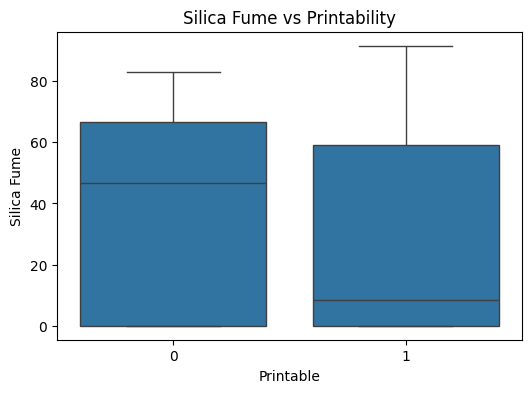

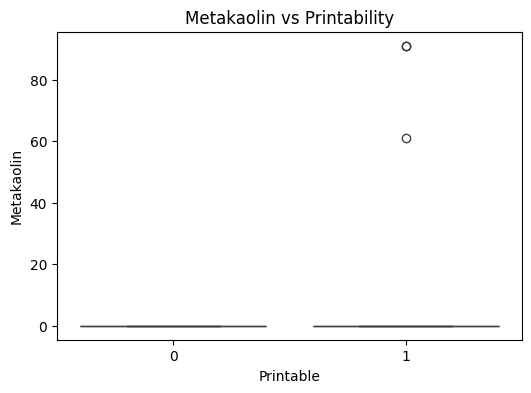

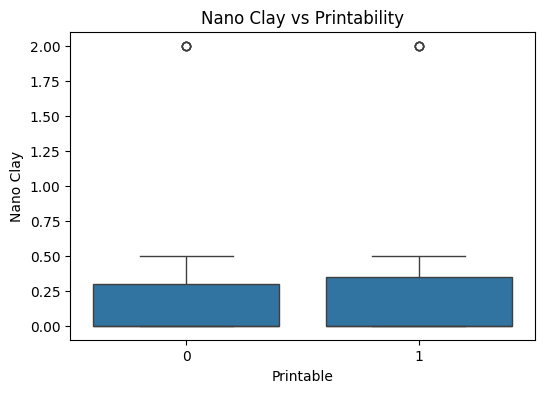

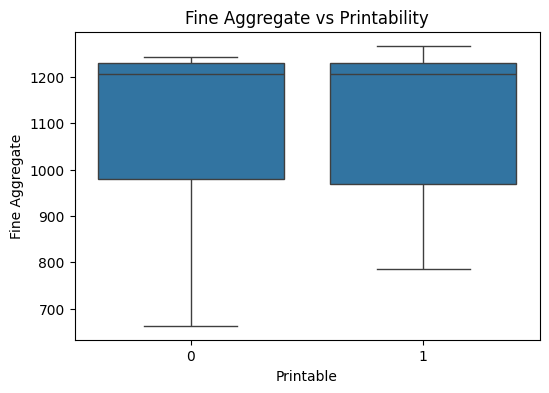

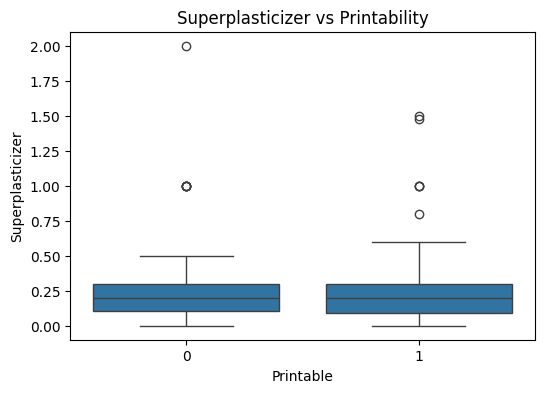

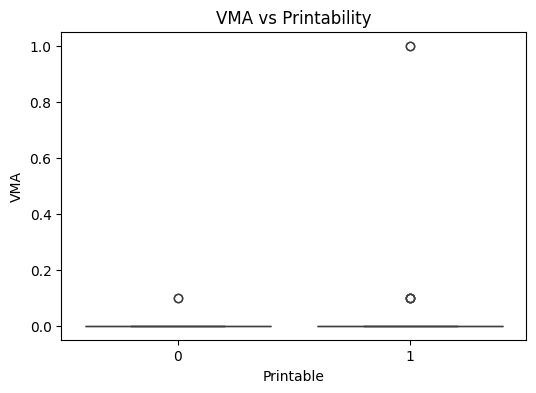

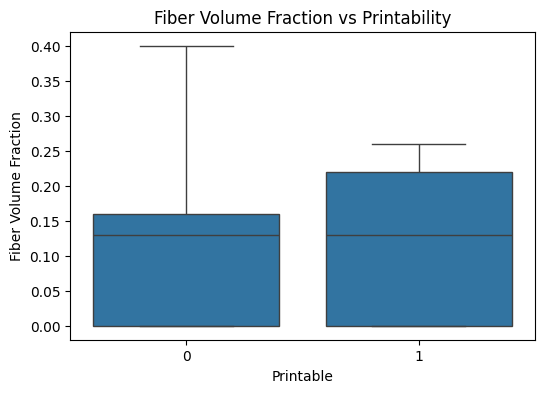

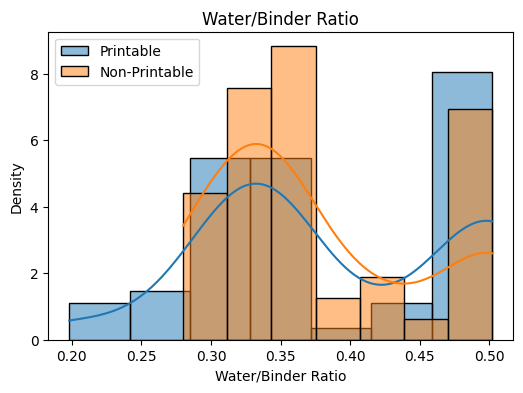

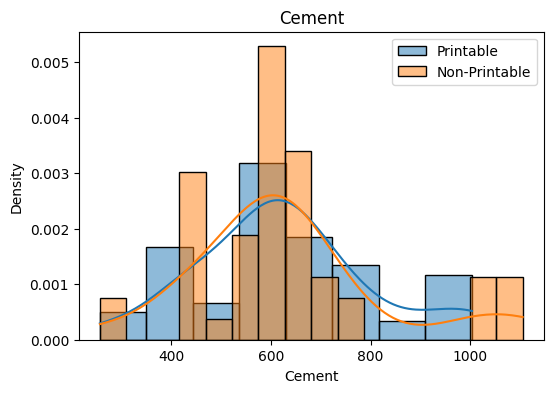

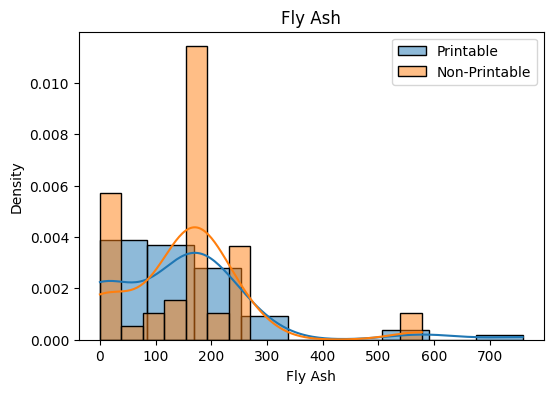

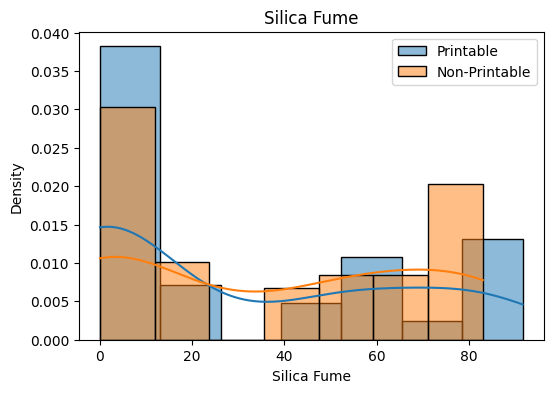

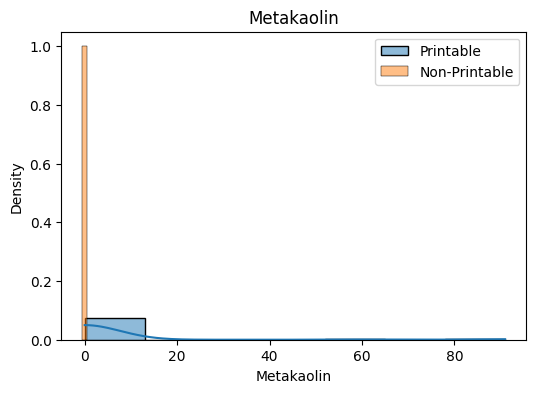

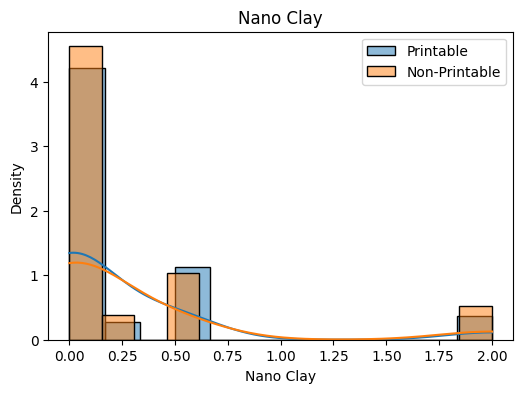

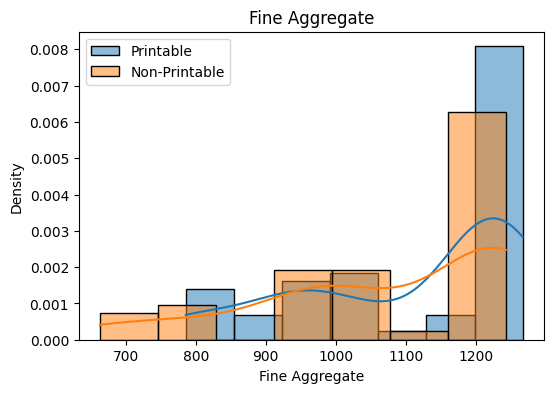

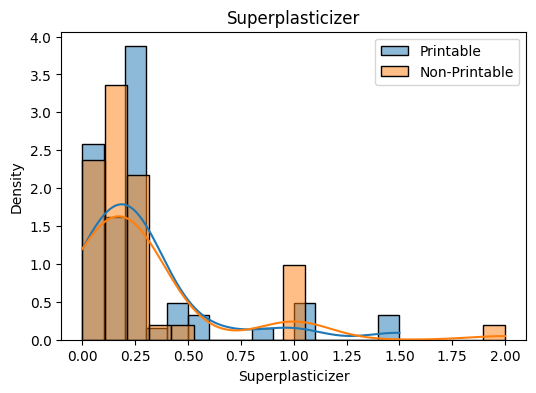

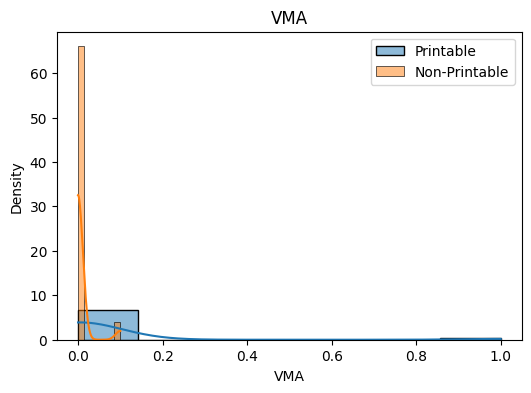

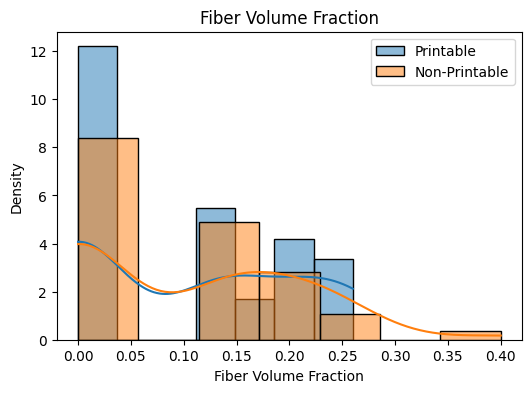

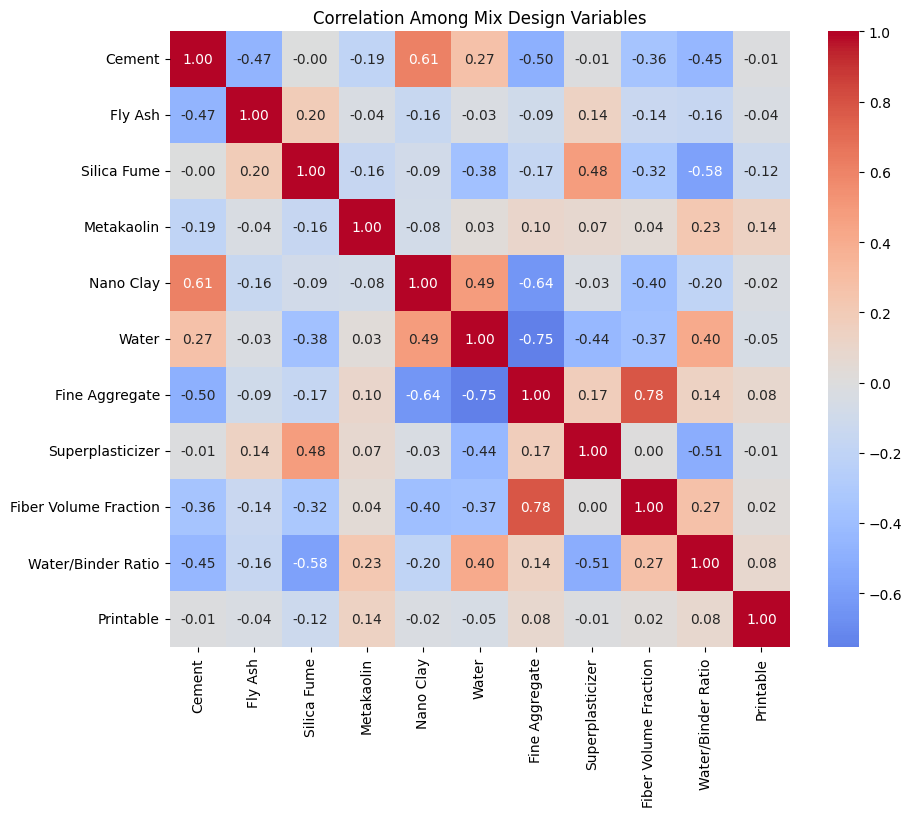

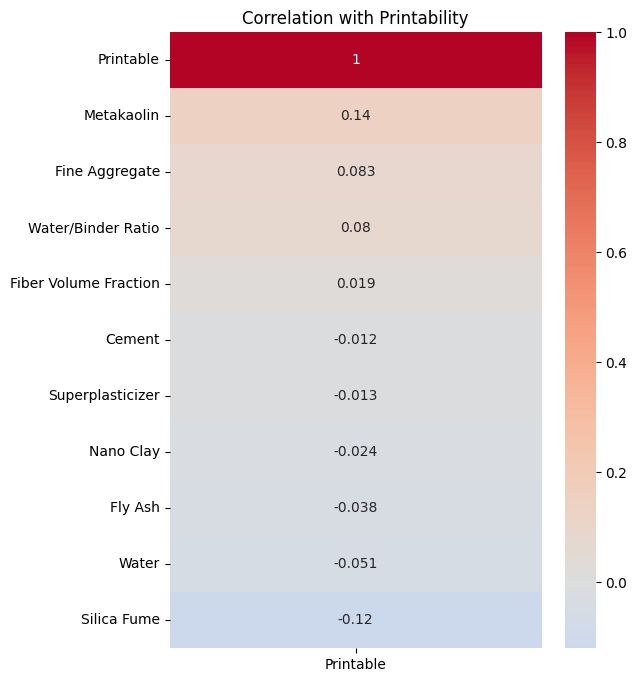

Accuracy = 0.4782608695652174
                 Feature  Importance
1                 Cement    0.147369
7       Superplasticizer    0.146964
6         Fine Aggregate    0.142730
3            Silica Fume    0.131331
2                Fly Ash    0.118055
0     Water/Binder Ratio    0.099821
9  Fiber Volume Fraction    0.095969
5              Nano Clay    0.076303
8                    VMA    0.026448
4             Metakaolin    0.015009


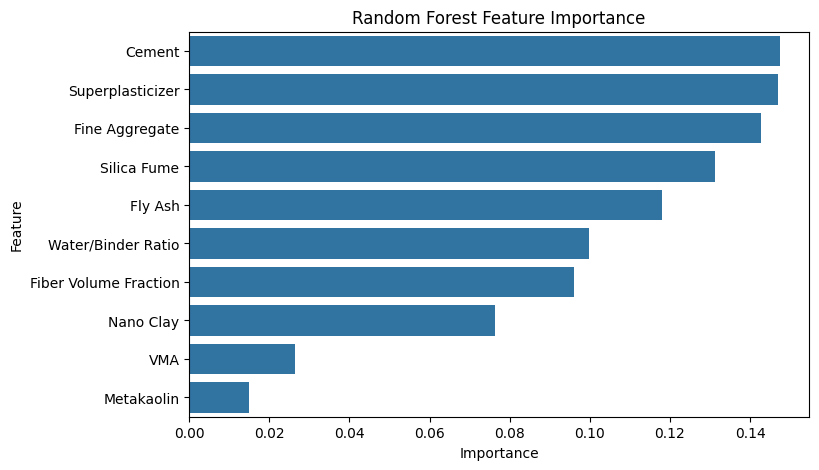

Water/Binder Ratio p = 0.4044
Cement p = 0.8343
Fly Ash p = 0.5865
Silica Fume p = 0.1897
Metakaolin p = 0.125
Nano Clay p = 0.9632
Fine Aggregate p = 0.6524
Superplasticizer p = 0.6603
VMA p = 0.2783
Fiber Volume Fraction p = 0.7945


In [ ]:
import pandas as pd

df = pd.read_csv("rheology dataset(Printability cluster) 1.csv")

df.head()
df.isnull().sum().sort_values(ascending=False)
df["Printable"] = df["Printable"].map({
    "Yes":1,
    "No":0
})

df["Printable"].value_counts()
features = [
    "Water/Binder Ratio",
    "Cement",
    "Fly Ash",
    "Silica Fume",
    "Metakaolin",
    "Nano Clay",
    "Fine Aggregate",
    "Superplasticizer",
    "VMA",
    "Fiber Volume Fraction"
]
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplots
for feature in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x="Printable",
        y=feature
    )

    plt.title(f"{feature} vs Printability")

    plt.show()

# Histograms
for feature in features:

    plt.figure(figsize=(6,4))

    sns.histplot(
        data=df[df["Printable"]==1],
        x=feature,
        label="Printable",
        kde=True,
        stat="density"
    )

    sns.histplot(
        data=df[df["Printable"]==0],
        x=feature,
        label="Non-Printable",
        kde=True,
        stat="density"
    )

    plt.legend()
    plt.title(feature)

    plt.show()

import numpy as np

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

mix_vars = [
    "Cement",
    "Fly Ash",
    "Silica Fume",
    "Metakaolin",
    "Nano Clay",
    "Water",
    "Fine Aggregate",
    "Superplasticizer",
    "Fiber Volume Fraction",
    "Water/Binder Ratio",
    "Printable"
]

corr = df[mix_vars].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Among Mix Design Variables")

plt.show()

vars_for_printability = [
    "Cement",
    "Fly Ash",
    "Silica Fume",
    "Metakaolin",
    "Nano Clay",
    "Water",
    "Fine Aggregate",
    "Superplasticizer",
    "Fiber Volume Fraction",
    "Water/Binder Ratio",
    "Printable"
]

corr = df[vars_for_printability].corr()

plt.figure(figsize=(6,8))

sns.heatmap(
    corr[["Printable"]].sort_values(
        by="Printable",
        ascending=False
    ),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation with Printability")

plt.show()

from sklearn.model_selection import train_test_split

X = df[features]
y = df["Printable"]

X = X.fillna(0)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf.fit(X,y)
importance = pd.DataFrame({
    "Feature":features,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf.fit(X_train,y_train)

pred = rf.predict(X_test)

print("Accuracy =", accuracy_score(y_test,pred))

print(importance)
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()
from scipy.stats import mannwhitneyu

for feature in features:

    printable = df[df["Printable"]==1][feature].dropna()

    non_printable = df[df["Printable"]==0][feature].dropna()

    if len(printable)>0 and len(non_printable)>0:

        stat,p = mannwhitneyu(
            printable,
            non_printable,
            alternative="two-sided"
        )

        print(feature, "p =", round(p,4))
